In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;

In [2]:
df = pd.read_csv("housing.csv");

In [3]:
df['income_cat'] = pd.cut(df['median_income'], bins = [0, 1.5, 3.0, 4.5, 6.0, np.inf], labels = [1, 2, 3, 4, 5]);

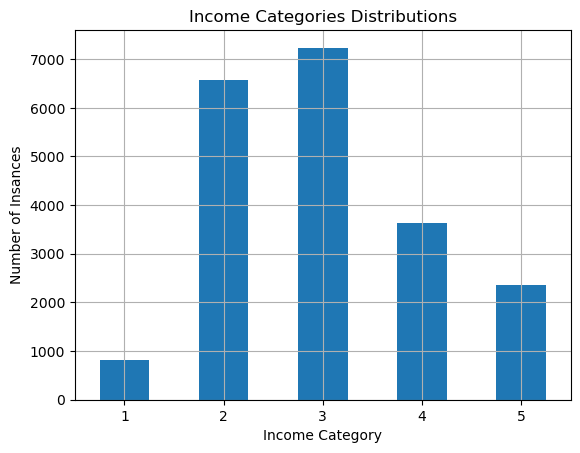

In [4]:
df["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True);
plt.title("Income Categories Distributions");
plt.xlabel("Income Category");
plt.ylabel("Number of Insances");

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3


In [6]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,2
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,2
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND,2
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND,2
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,89400,INLAND,2


In [7]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  object  
 10  income_cat          20640 non-null  category
dtypes: category(1), float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [8]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


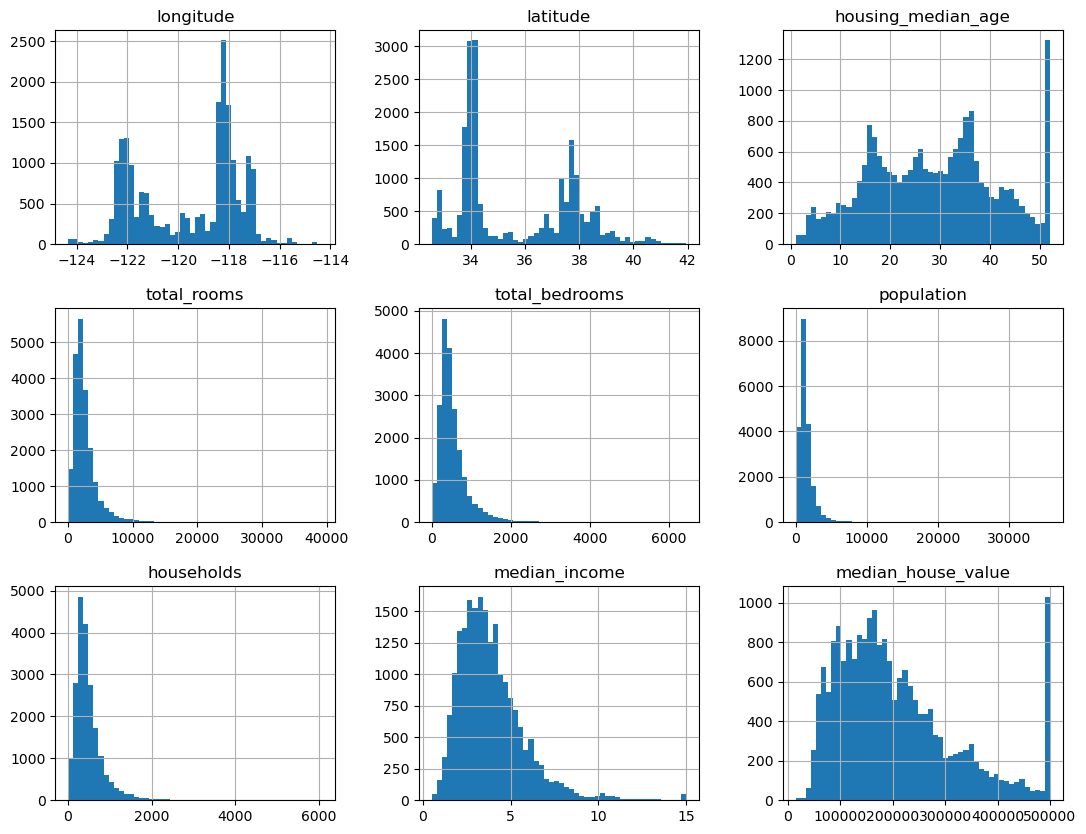

In [10]:
df.hist(bins = 50, figsize = (13, 10));

In [11]:
def shuffle_and_split(data, test_ratio):
    np.random.seed(42); # Set the seed for reproducibility:-
    shuffled_indices = np.random.permutation(len(data)); # This returns shuffled indices:-
    test_set_size = int(len(data) * test_ratio);
    test_indices = shuffled_indices[:test_set_size];
    train_indices = shuffled_indices[test_set_size:];
    return data.iloc[train_indices], data.iloc[test_indices];

In [12]:
train, test = shuffle_and_split(df, 0.2);

In [13]:
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
14196,-117.03,32.71,33,3126,627.0,2300,623,3.2596,103000,NEAR OCEAN,3
8267,-118.16,33.77,49,3382,787.0,1314,756,3.8125,382100,NEAR OCEAN,3
17445,-120.48,34.66,4,1897,331.0,915,336,4.1563,172600,NEAR OCEAN,3
14265,-117.11,32.69,36,1421,367.0,1418,355,1.9425,93400,NEAR OCEAN,2
2271,-119.80,36.78,43,2382,431.0,874,380,3.5542,96500,INLAND,3


In [14]:
test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20046,-119.01,36.06,25,1505,NaN,1392,359,1.6812,47700,INLAND,2
3024,-119.46,35.14,30,2943,NaN,1565,584,2.5313,45800,INLAND,2
15663,-122.44,37.80,52,3830,NaN,1310,963,3.4801,500001,NEAR BAY,3
20484,-118.72,34.28,17,3051,NaN,1705,495,5.7376,218600,<1H OCEAN,4
9814,-121.93,36.62,34,2351,NaN,1063,428,3.7250,278000,NEAR OCEAN,3


In [15]:
from sklearn.model_selection import StratifiedShuffleSplit;
split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42);
for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index];
    strat_test_set = df.loc[test_index];

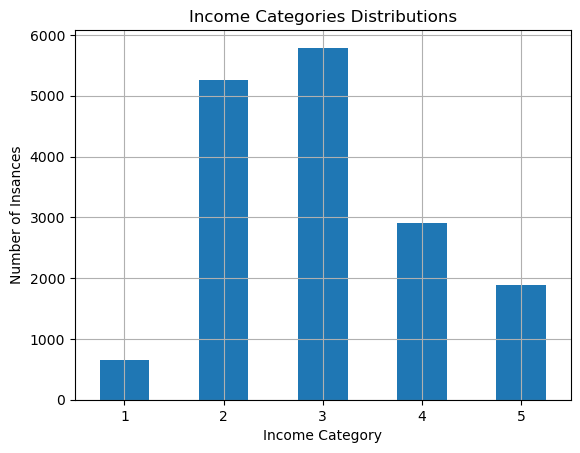

In [16]:
strat_train_set["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True);
plt.title("Income Categories Distributions");
plt.xlabel("Income Category");
plt.ylabel("Number of Insances");

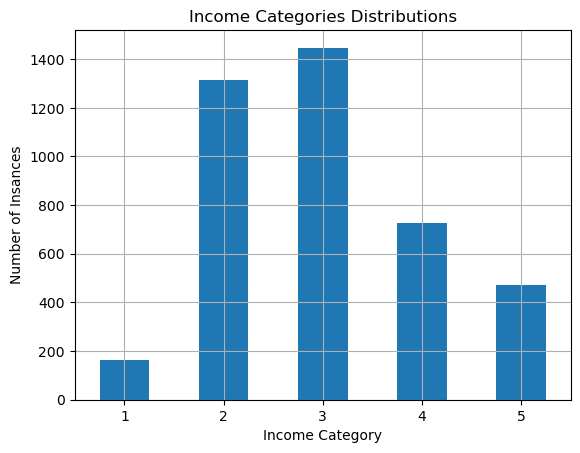

In [17]:
strat_test_set["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True);
plt.title("Income Categories Distributions");
plt.xlabel("Income Category");
plt.ylabel("Number of Insances");

In [18]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12655,-121.46,38.52,29,3873,797.0,2237,706,2.1736,72100,INLAND,2
15502,-117.23,33.09,7,5320,855.0,2015,768,6.3373,279600,NEAR OCEAN,5
2908,-119.04,35.37,44,1618,310.0,667,300,2.8750,82700,INLAND,2
14053,-117.13,32.75,24,1877,519.0,898,483,2.2264,112500,NEAR OCEAN,2
20496,-118.70,34.28,27,3536,646.0,1837,580,4.4964,238300,<1H OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14,6665,1231.0,2026,1001,5.0900,268500,<1H OCEAN,4
12661,-121.42,38.51,15,7901,1422.0,4769,1418,2.8139,90400,INLAND,2
19263,-122.72,38.44,48,707,166.0,458,172,3.1797,140400,<1H OCEAN,3
19140,-122.70,38.31,14,3155,580.0,1208,501,4.1964,258100,<1H OCEAN,3
